#  Model Training & Evaluation
**Project:** Predictive Modeling and Risk Scoring for Bank Customer Churn

## 2.1 Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve, average_precision_score
)

os.makedirs("../results/models", exist_ok=True)
os.makedirs("../models",         exist_ok=True)
RANDOM_SEED = 42
print("Ready.")


Ready.


## 2.2 Load preprocessed data

In [ ]:
data = joblib.load("../data/processed/churn_preprocessed.pkl")

X_train    = data["X_train"]
X_test     = data["X_test"]
X_train_sc = data["X_train_sc"]
X_test_sc  = data["X_test_sc"]
y_train    = data["y_train"]
y_test     = data["y_test"]
feature_cols    = data["feature_cols"]
scale_pos_weight = data["scale_pos_weight"]

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Churn rate — train: {y_train.mean()*100:.1f}%  test: {y_test.mean()*100:.1f}%")


X_train: (8000, 23)  X_test: (2000, 23)
Churn rate — train: 20.4%  test: 20.3%


## 2.3 Define models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        random_state=RANDOM_SEED, C=0.1
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6, class_weight="balanced",
        random_state=RANDOM_SEED, min_samples_leaf=20
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10,
        class_weight="balanced", random_state=RANDOM_SEED,
        n_jobs=-1, min_samples_leaf=10
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        random_state=RANDOM_SEED
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc", random_state=RANDOM_SEED,
        n_jobs=-1
    ),
}

# Models needing scaled input
NEEDS_SCALING = {"Logistic Regression"}

print("Models defined:", list(models.keys()))


Models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


## 2.4 Train & evaluate all models

In [ ]:
def get_XY(name):
    if name in NEEDS_SCALING:
        return X_train_sc, X_test_sc
    return X_train, X_test

results = []
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, model in models.items():
    Xtr, Xte = get_XY(name)

    # CV AUC
    cv_auc = cross_val_score(model, Xtr, y_train,
                              cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    # Fit on full train
    model.fit(Xtr, y_train)
    trained_models[name] = model

    # Test predictions
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    row = {
        "Model"    : name,
        "CV_AUC"   : round(cv_auc, 4),
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1"       : round(f1_score(y_test, y_pred), 4),
        "y_prob"   : y_prob,
        "y_pred"   : y_pred,
    }
    results.append(row)
    print(f"  {name:25s} | AUC: {row['AUC']:.4f}  F1: {row['F1']:.4f}  Recall: {row['Recall']:.4f}")

results_df = pd.DataFrame([{k: v for k, v in r.items()
                             if k not in ("y_prob","y_pred")} for r in results])
results_df.to_csv("../results/models/model_comparison.csv", index=False)
print("\n=== Model Comparison ===")
print(results_df.sort_values("AUC", ascending=False).to_string(index=False))


  Logistic Regression       | AUC: 0.7748  F1: 0.4983  Recall: 0.7027
  Decision Tree             | AUC: 0.8410  F1: 0.5735  Recall: 0.7862
  Random Forest             | AUC: 0.8635  F1: 0.6034  Recall: 0.7420
  Gradient Boosting         | AUC: 0.8598  F1: 0.5762  Recall: 0.4693
  XGBoost                   | AUC: 0.8479  F1: 0.5996  Recall: 0.6658

=== Model Comparison ===
              Model  CV_AUC    AUC  Accuracy  Precision  Recall     F1
      Random Forest  0.8562 0.8635    0.8015     0.5084  0.7420 0.6034
  Gradient Boosting  0.8575 0.8598    0.8595     0.7461  0.4693 0.5762
            XGBoost  0.8497 0.8479    0.8190     0.5453  0.6658 0.5996
      Decision Tree  0.8323 0.8410    0.7620     0.4513  0.7862 0.5735
Logistic Regression  0.7659 0.7748    0.7120     0.3860  0.7027 0.4983


## 2.5 ROC Curves

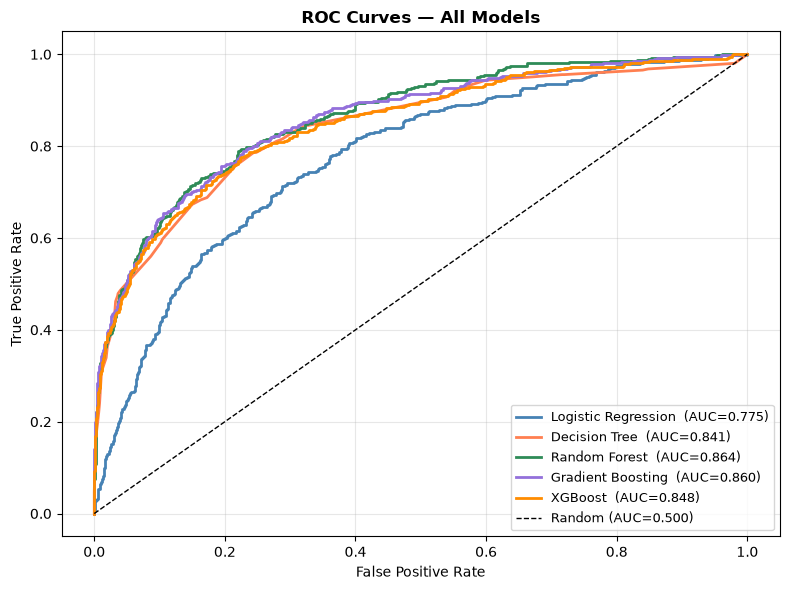

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["steelblue", "coral", "seagreen", "mediumpurple", "darkorange"]

for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f"{r['Model']}  (AUC={r['AUC']:.3f})")

ax.plot([0,1],[0,1],"k--", lw=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/models/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.6 Precision-Recall Curves

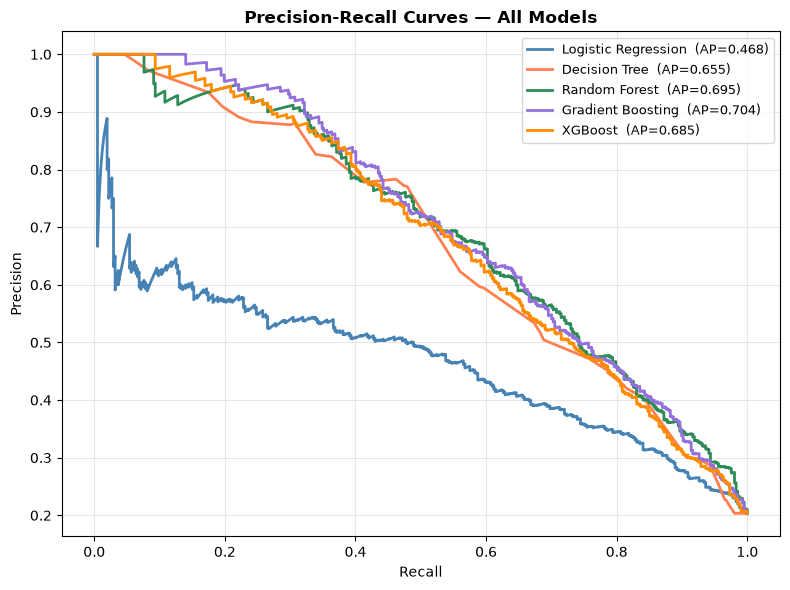

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for r, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_test, r["y_prob"])
    ap = average_precision_score(y_test, r["y_prob"])
    ax.plot(rec, prec, lw=2, color=color,
            label=f"{r['Model']}  (AP={ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/models/precision_recall_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.7 Confusion Matrices

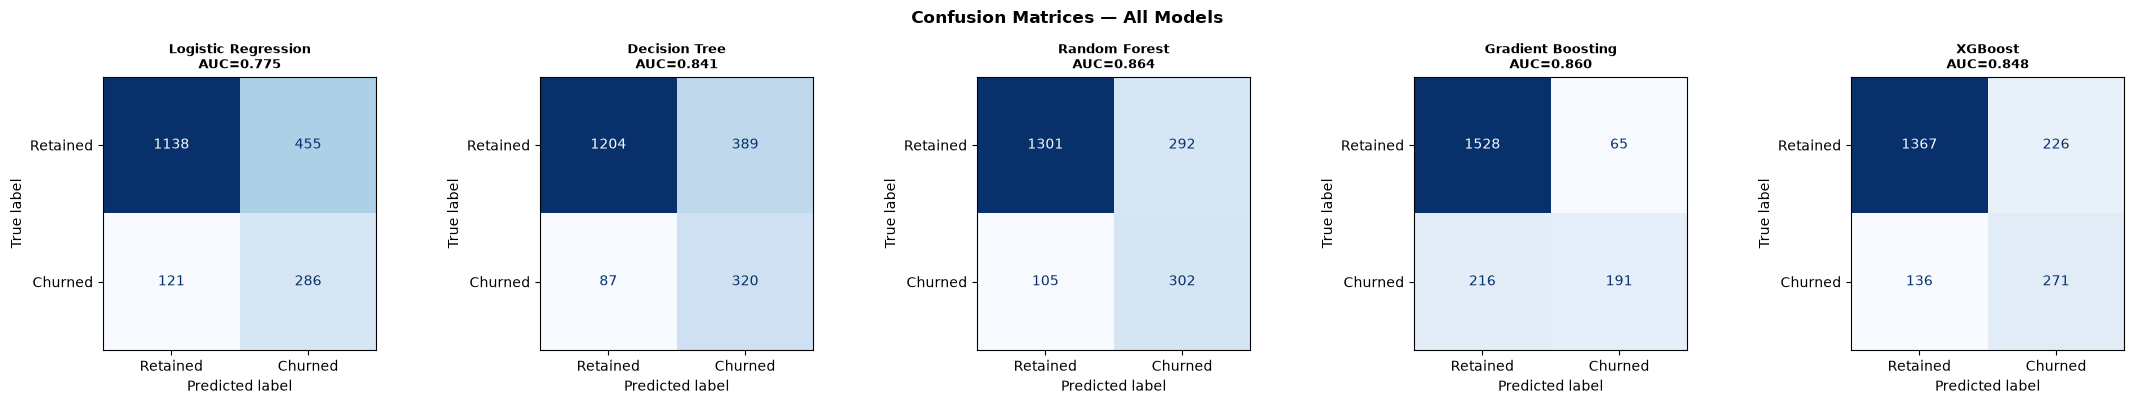

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Retained","Churned"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{r['Model']}\nAUC={r['AUC']:.3f}", fontsize=9, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/models/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.8 Metrics comparison bar chart

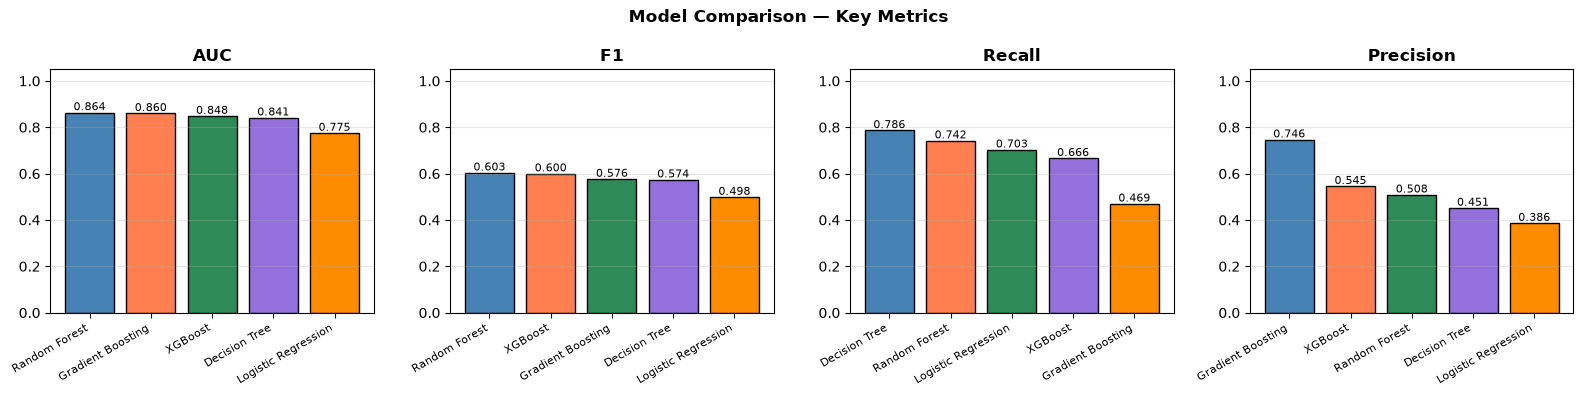

In [ ]:
metrics = ["AUC", "F1", "Recall", "Precision"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes, metrics):
    sub = results_df.sort_values(metric, ascending=False)
    bars = ax.bar(range(len(sub)), sub[metric], color=colors, edgecolor="black")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub["Model"], rotation=30, ha="right", fontsize=8)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, sub[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", fontsize=8)

plt.suptitle("Model Comparison — Key Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/models/metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.9 Churn Risk Score — Threshold Analysis

 Threshold  Precision  Recall    F1  Flagged
      0.10      0.224   0.993 0.366     1801
      0.15      0.241   0.985 0.388     1661
      0.20      0.270   0.980 0.423     1480
      0.25      0.293   0.951 0.448     1320
      0.30      0.325   0.929 0.482     1163
      0.35      0.361   0.894 0.515     1007
      0.40      0.401   0.848 0.544      861
      0.45      0.452   0.803 0.579      723
      0.50      0.508   0.742 0.603      594
      0.55      0.574   0.686 0.625      486
      0.60      0.633   0.607 0.620      390
      0.65      0.694   0.541 0.608      317
      0.70      0.755   0.477 0.584      257
      0.75      0.811   0.391 0.527      196
      0.80      0.905   0.305 0.456      137
      0.85      0.942   0.199 0.329       86


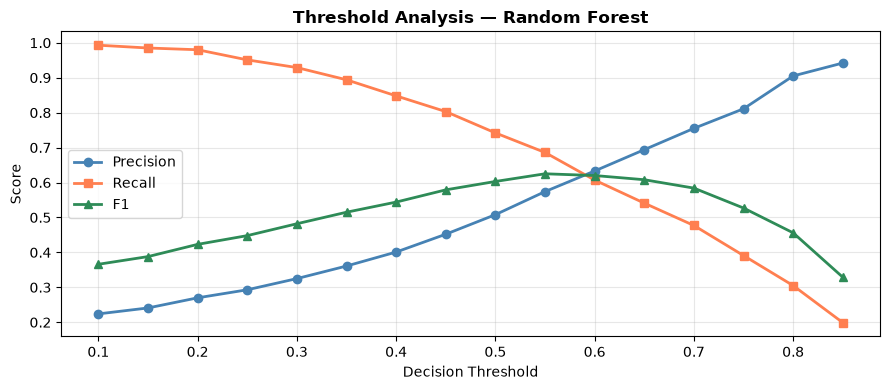

In [ ]:
# Use XGBoost (best model) for threshold analysis
best_model_name = results_df.sort_values("AUC", ascending=False).iloc[0]["Model"]
best_result     = next(r for r in results if r["Model"] == best_model_name)
y_prob_best     = best_result["y_prob"]

thresholds = np.arange(0.1, 0.9, 0.05)
th_results = []

for th in thresholds:
    y_pred_th = (y_prob_best >= th).astype(int)
    th_results.append({
        "Threshold": round(th, 2),
        "Precision": round(precision_score(y_test, y_pred_th, zero_division=0), 3),
        "Recall"   : round(recall_score(y_test, y_pred_th, zero_division=0), 3),
        "F1"       : round(f1_score(y_test, y_pred_th, zero_division=0), 3),
        "Flagged"  : int(y_pred_th.sum()),
    })

th_df = pd.DataFrame(th_results)
print(th_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(th_df["Threshold"], th_df["Precision"], "o-", color="steelblue",  label="Precision", lw=2)
ax.plot(th_df["Threshold"], th_df["Recall"],    "s-", color="coral",      label="Recall",    lw=2)
ax.plot(th_df["Threshold"], th_df["F1"],        "^-", color="seagreen",   label="F1",        lw=2)
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title(f"Threshold Analysis — {best_model_name}", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/models/threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.10 Generate Risk Scores

=== Risk Tier Distribution ===
RiskTier
Low Risk       1139
Medium Risk     604
High Risk       257
Name: count, dtype: int64



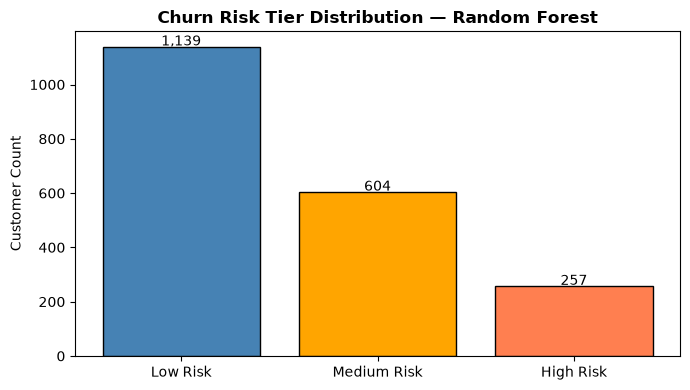

In [ ]:
# Assign risk tiers based on churn probability
def risk_tier(prob):
    if prob >= 0.70:  return "High Risk"
    elif prob >= 0.40: return "Medium Risk"
    else:              return "Low Risk"

_, Xte = get_XY(best_model_name)
y_prob_all = trained_models[best_model_name].predict_proba(Xte)[:, 1]

risk_df = pd.DataFrame({
    "ChurnProbability": y_prob_all,
    "RiskTier"        : [risk_tier(p) for p in y_prob_all],
    "Actual"          : y_test.values
})

print("=== Risk Tier Distribution ===")
print(risk_df["RiskTier"].value_counts())
print()

tier_colors = {"High Risk": "coral", "Medium Risk": "orange", "Low Risk": "steelblue"}
tier_counts = risk_df["RiskTier"].value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(tier_counts.index, tier_counts.values,
               color=[tier_colors[t] for t in tier_counts.index], edgecolor="black")
plt.title(f"Churn Risk Tier Distribution — {best_model_name}", fontweight="bold")
plt.ylabel("Customer Count")
for bar, val in zip(bars, tier_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../results/models/risk_tier_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.11 Save models

In [ ]:
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"../models/{safe_name}.pkl")

# Save best model explicitly
joblib.dump(trained_models[best_model_name], "../models/best_model.pkl")
joblib.dump({"name": best_model_name, "results": results_df}, "../models/model_metadata.pkl")
joblib.dump(risk_df, "../results/models/risk_scores.pkl")

print("Models saved to models/")
print(f"Best model: {best_model_name}")



Models saved to models/
Best model: Random Forest
